# 10v5_02 (v5.1) — Regime-safe Mode-A scaling + spectrum-model freeze

**What changed vs v5.** The Mode-A rankers train only on `*_MODE_A` manifests, derived by
`10v5_03_tl_regime_audit`: queries whose truth is in the pool with at least one eligible
`mirror_aware` reference. The scale model is **selected on TL_EVAL_MODE_A only**.
TL_EVAL_ALL is the end-to-end stress metric. TL_EVAL_STANDARD_ONLY and TL_EVAL_REF_ABSENT show
where Mode A fails. HOST confirms. The v5.1 rule (`casmi.ranking.scaling.V51_RULE`) is written
to `preregistration_v5_1.json` before any metric exists.

The recipe is the unchanged v4b V1: `BASE_FEATURES` in order, `LGBM_PARAMS`, lambdarank, seed 42,
one group per query, and 5 connectivity folds. There is **no** reference-count, availability,
source or regime feature, and no tuning. The executed v5 version of this notebook is archived
as `10v5_02_scaling_and_freeze.v5_executed.ipynb`.

In [1]:
import sys, json, hashlib
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists() and (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from casmi.paths import get_project_paths
from casmi.candidates.generator import CandidateGenerator, dedupe_pool_to_connectivity
from casmi.candidates.mass_index import MassIndex
from casmi.qcr.aggregate import aggregate_deterministic
from casmi.qcr.context import HOST_INGEST_LIB, SEED, config_hash, v4b_paths, v5_paths
from casmi.qcr.fingerprint import code_version
from casmi.qcr.settlement import load_settlement_or_refuse
from casmi.ranking.baselines import b1, fusion
from casmi.ranking.freeze import feature_order_hash, mirror_aware_protocol_hash, model_file_hashes
from casmi.ranking.lambdamart import BASE_FEATURES, LGBM_PARAMS, fit_fold_models, predict_by_fold, save_fold_models
from casmi.ranking.manifests import load_manifest
from casmi.ranking.mass_likelihood import MassLikelihoodModel
from casmi.ranking.rank_eval import per_query_metrics, rank_by_keys, summarize
from casmi.ranking.scaling import (
    EVAL_POPULATIONS, MODE_A_HEADLINE_CANDIDATES, MODE_A_MODEL_MANIFEST, MODE_A_NESTED_ORDER, MODE_A_PAIRED_COMPARISONS,
    MODE_A_SCALE_MODELS, POOL_BIN_EDGES, V51_RULE, density_reweighted_mrr, pool_size_stratification, population_ids, scale_decision,
    score_population, select_mode_a_headline,
)
from casmi.ranking.selection import DevSelectionLock, lock_dev_selection, require_dev_selection_lock, write_preregistration
from casmi.validation.cluster_bootstrap import cluster_bootstrap_mean, paired_comparison_row
from casmi.validation.decision_log import log_decision
from casmi.validation.regime_audit import MODE_A_MIRROR, REF_ABSENT, load_regimes, metrics_by_regime

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 220)
paths = get_project_paths()
vp, D = v4b_paths(paths), v5_paths(paths)
REG_DIR = D['root'] / 'regimes'
PREREG = D['freeze'] / 'preregistration_v5_1.json'
N_BOOT, K_STRESS, KEY = 2000, (1, 3, 5), 'candidate_connectivity_key'
RESULTS = {'tl_eval': {}, 'host': {}, 'oof': {}}


def jdump(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2, default=str), encoding='utf-8')

## 0. Preconditions + v5.1 pre-registration (before any metric)

In [2]:
settlement = load_settlement_or_refuse(vp.settlement_json)
ARTS = settlement['evidence_artifacts']
SIM_HASH = config_hash(settlement['similarity_config'])
PARAMS_HASH = hashlib.sha256(json.dumps(LGBM_PARAMS, sort_keys=True).encode()).hexdigest()[:16]
prereg = write_preregistration(PREREG, rule=V51_RULE, extra={'lgbm_params': LGBM_PARAMS, 'features': BASE_FEATURES, 'seed': SEED, 'n_boot': N_BOOT,
                                                             'populations': list(EVAL_POPULATIONS), 'pool_bin_edges': [str(e) for e in POOL_BIN_EDGES]})
print('v5.1 rule sha256:', prereg['rule_sha256'])
log_decision(decision='v5.1 regime-safe Mode-A scale + headline rules pre-registered (select on TL_EVAL_MODE_A)',
             evidence_used=f"sha256 {prereg['rule_sha256']}", host_visible=False, category='pre_registered_choice',
             log_path=paths.outputs / 'decision_log.jsonl')
ROUTE = json.loads((D['root'] / 'project_route.json').read_text(encoding='utf-8')) if (D['root'] / 'project_route.json').exists() else {'project_route': 'NOT_COMPUTED'}
print('project route (from 10v5_03):', ROUTE.get('project_route'))

v5.1 rule sha256: ba90aa1c4a129f2e2c765889604347cbe74421258371a8b09419cd23aab556cf
project route (from 10v5_03): RESOLVE_TEST_PROTOCOL


## 1. TL_EVAL + regimes, Mode-A training manifests, persisted features (nothing rebuilt)

In [3]:
TL_MAN, TL_META = load_manifest('TL_EVAL', D['manifests'])
TL_REG = load_regimes('TL_EVAL', REG_DIR)
assert set(TL_REG['query_id']) == set(TL_MAN['query_id']), 'TL_EVAL regimes out of date -- rerun 10v5_03'
TL_IDS = TL_MAN['query_id'].tolist()
POP_IDS = {p: population_ids(TL_REG, p) for p in EVAL_POPULATIONS}
display(pd.Series({p: len(v) for p, v in POP_IDS.items()}, name='n_queries').to_frame())
CLUSTER_TL = TL_MAN.set_index('query_id')['connectivity_key'].to_dict()
TL = pd.read_parquet(D['features'] / 'TL_EVAL_mirror_aware.parquet')

host_q = pd.read_parquet(vp.host_processed / 'host_holdout_spectra.parquet')
HOST_IDS = host_q['query_id'].tolist()
CLUSTER_HOST = host_q.set_index('query_id')['true_connectivity_key'].to_dict()
host_meta = host_q[['query_id', 'fold', 'true_connectivity_key', 'instrument_type', 'adduct']].rename(columns={'instrument_type': 'instrument'})
HOSTF = pd.read_parquet(ARTS['host_features_mirror_aware']).drop(columns=['fold'], errors='ignore').merge(host_meta, on='query_id', how='left')
HOST_REG = load_regimes('HOST', REG_DIR) if (REG_DIR / 'HOST_query_regimes.parquet').exists() else None

TRAIN, TRAIN_META, STATUS = {}, {}, {}
for mid, man in MODE_A_MODEL_MANIFEST.items():
    base = man.replace('_MODE_A', '')
    if not (D['manifests'] / f'{man}.parquet').exists() or not (D['features'] / f'{base}_mirror_aware.parquet').exists():
        STATUS[mid] = 'NOT_RUN'
        continue
    m, meta = load_manifest(man, D['manifests'])
    build = json.loads((D['features'] / f'{base}_mirror_aware.build.json').read_text(encoding='utf-8'))
    assert build['evidence_fingerprint'] == settlement['evidence_fingerprint'], f'{base}: features built on different evidence'
    f = pd.read_parquet(D['features'] / f'{base}_mirror_aware.parquet')
    f = f[f['query_id'].isin(set(m['query_id']))]              # Mode-A filter applied to persisted features: no rebuild
    truth_ok = f[f['is_true_candidate']].groupby('query_id')['n_reference_spectra'].min().ge(1)
    assert truth_ok.all() and truth_ok.size == m['query_id'].nunique(), f'{man}: training group without a truth mirror reference'
    assert not (set(m['connectivity_key']) & set(TL_MAN['connectivity_key'])) and not (set(m['connectivity_key']) & set(host_q['true_connectivity_key']))
    TRAIN[mid], TRAIN_META[mid] = f, meta
    print(f"{mid}: {m['query_id'].nunique():,} Mode-A training queries (truth mirror reference 100%); "
          f"decoy no-reference rate {(f.loc[~f['is_true_candidate'], 'n_reference_spectra'] == 0).mean():.3f} (audit only)")
nested = [m for m in MODE_A_NESTED_ORDER if m in TRAIN]
for a, b in zip(nested[:-1], nested[1:]):
    assert set(TRAIN[a]['query_id']) <= set(TRAIN[b]['query_id']), f'{a} not nested in {b}'

,n_queries
TL_EVAL_MODE_A,14
TL_EVAL_ALL,1000
TL_EVAL_STANDARD_ONLY,984
TL_EVAL_REF_ABSENT,2
TL_EVAL_POOL_ABSENT,0


V1_RND_1K_MODE_A: 335 Mode-A training queries (truth mirror reference 100%); decoy no-reference rate 0.068 (audit only)
V1_TL_1K_MODE_A: 18 Mode-A training queries (truth mirror reference 100%); decoy no-reference rate 0.533 (audit only)


## 2. Train the Mode-A scale models (exact V1 recipe)

In [4]:
MODELS, N_TRAIN = {}, {}
CODE_VERSION = code_version()
for mid, tr in TRAIN.items():
    man = MODE_A_MODEL_MANIFEST[mid]
    folds = sorted(tr['fold'].unique())
    assert len(folds) == 5, f'{mid}: expected 5 connectivity folds, got {folds}'
    models, _ = fit_fold_models(tr, BASE_FEATURES, fold_col='fold', folds=folds, params=LGBM_PARAMS)
    out = D['models'] / mid
    save_fold_models(models, out, BASE_FEATURES, LGBM_PARAMS, tr['query_id'].unique(), extra={
        'model_id': mid, 'training_manifest': man, 'training_manifest_hash': TRAIN_META[mid]['manifest_sha256'],
        'similarity_config_hash': SIM_HASH, 'lgbm_params_hash': PARAMS_HASH, 'feature_order_hash': feature_order_hash(BASE_FEATURES),
        'seed': SEED, 'code_version': CODE_VERSION, 'evidence_fingerprint': settlement['evidence_fingerprint'],
        'fold_manifest': [{'fold': int(f), 'n_train_queries': int(tr.loc[tr.fold != f, 'query_id'].nunique()),
                           'n_heldout_queries': int(tr.loc[tr.fold == f, 'query_id'].nunique())} for f in folds]})
    jdump(BASE_FEATURES, out / 'feature_names.json')
    oof = tr[['query_id', KEY, 'abs_mass_error_ppm', 'is_true_candidate', 'fold']].assign(score=predict_by_fold(models, tr, BASE_FEATURES).to_numpy())
    oof.to_parquet(out / 'oof_rows.parquet', index=False)
    RESULTS['oof'][mid] = summarize(per_query_metrics(rank_by_keys(oof, [('score', False), ('abs_mass_error_ppm', True), (KEY, True)]),
                                                      tr['query_id'].unique().tolist()))
    MODELS[mid], STATUS[mid], N_TRAIN[mid] = models, 'OK', int(tr['query_id'].nunique())
    print(f'{mid}: {N_TRAIN[mid]:,} training queries | own-population OOF MRR@25 (diagnostic) {RESULTS["oof"][mid]["mrr_at_25"]:.4f}')
print('status:', STATUS)

V1_RND_1K_MODE_A: 335 training queries | own-population OOF MRR@25 (diagnostic) 0.7327
V1_TL_1K_MODE_A: 18 training queries | own-population OOF MRR@25 (diagnostic) 0.8611
status: {'V1_TL_3K_MODE_A': 'NOT_RUN', 'V1_TL_10K_MODE_A': 'NOT_RUN', 'V1_RND_1K_MODE_A': 'OK', 'V1_TL_1K_MODE_A': 'OK'}


# SELECTION PHASE: TL_EVAL_MODE_A only

## 3. Score the whole TL_EVAL once (fold-mean), then report every population

In [5]:
v4b_lock = json.loads((vp.out / 'dev_selection_lock.json').read_text(encoding='utf-8'))
B5_ALPHA, B5_STD = float(v4b_lock['alphas']['B5']), v4b_lock['dev_standardizer']
mass_model = MassLikelihoodModel.from_dict(json.loads((vp.out / 'metrics' / 'mass_likelihood_model.json').read_text(encoding='utf-8')))


def with_mass_loglik(df):
    d = df.rename(columns={'instrument': 'instrument_type'})
    return d.assign(mass_loglik=mass_model.loglik(d)[0])


TL_PQ = {mid: score_population(models, TL, BASE_FEATURES, TL_IDS)[0] for mid, models in MODELS.items()}
TL_B = with_mass_loglik(TL)
TL_PQ['B5_frozen_v4b'] = fusion(TL_B, TL_IDS, 'modified_cosine_max', B5_ALPHA, B5_STD)
TL_PQ['B1_mass'] = b1(TL_B, TL_IDS)


def pop_metrics(pq, ids):
    return summarize(pq[pq['query_id'].isin(set(ids))])


for m, pq in TL_PQ.items():
    pq.to_parquet(D['metrics'] / f'v51_tl_eval_per_query_{m}.parquet', index=False)
    RESULTS['tl_eval'][m] = {p: pop_metrics(pq, POP_IDS[p]) for p in EVAL_POPULATIONS}
pop_table = pd.DataFrame([{'model': m, 'population': p, **v} for m, d in RESULTS['tl_eval'].items() for p, v in d.items()])
pop_table.to_csv(D['metrics'] / 'v51_tl_eval_population_metrics.csv', index=False)
display(pop_table.pivot_table(index='model', columns='population', values='mrr_at_25').round(4))
display(pop_table.pivot_table(index='model', columns='population', values='n_queries'))

population,TL_EVAL_ALL,TL_EVAL_MODE_A,TL_EVAL_REF_ABSENT,TL_EVAL_STANDARD_ONLY
model,,,,
B1_mass,0.1418,0.2129,0.125,0.1408
B5_frozen_v4b,0.1274,0.9286,0.100,0.1161
V1_RND_1K_MODE_A,0.0178,0.8810,0.000,0.0055
V1_TL_1K_MODE_A,0.0625,1.0000,0.000,0.0493


population,TL_EVAL_ALL,TL_EVAL_MODE_A,TL_EVAL_POOL_ABSENT,TL_EVAL_REF_ABSENT,TL_EVAL_STANDARD_ONLY
model,,,,,
B1_mass,1000.0,14.0,0.0,2.0,984.0
B5_frozen_v4b,1000.0,14.0,0.0,2.0,984.0
V1_RND_1K_MODE_A,1000.0,14.0,0.0,2.0,984.0
V1_TL_1K_MODE_A,1000.0,14.0,0.0,2.0,984.0


## 4. Connectivity bootstrap on TL_EVAL_MODE_A (selection population); ALL reported too

In [6]:
def pq_sub(pq, ids):
    return pq[pq['query_id'].isin(set(ids))]


ci_rows, boot = [], {}
for pop in ('TL_EVAL_MODE_A', 'TL_EVAL_ALL'):
    for m, pq in TL_PQ.items():
        s = pq_sub(pq, POP_IDS[pop])
        ci_rows.append({'population': pop, 'model': m, **cluster_bootstrap_mean(s['rr'].to_numpy(), s['query_id'].map(CLUSTER_TL).to_numpy(), n_boot=N_BOOT, seed=SEED)})
    pairs = [p for p in MODE_A_PAIRED_COMPARISONS if p[0] in TL_PQ and p[1] in TL_PQ] + [(m, 'B5_frozen_v4b') for m in MODE_A_HEADLINE_CANDIDATES if m in TL_PQ]
    boot[pop] = pd.DataFrame([paired_comparison_row(a, pq_sub(TL_PQ[a], POP_IDS[pop]), b, pq_sub(TL_PQ[b], POP_IDS[pop]), CLUSTER_TL, n_boot=N_BOOT, seed=SEED)
                              for a, b in pairs])
tl_ci = pd.DataFrame(ci_rows)
tl_ci.to_parquet(D['bootstrap'] / 'v51_tl_eval_mrr_ci.parquet', index=False)
for pop, b in boot.items():
    b.to_parquet(D['bootstrap'] / f'v51_{pop}_paired.parquet', index=False)
    print(f'\n== paired deltas on {pop}'); display(b[['comparison', 'delta', 'ci_low', 'ci_high', 'excludes_zero', 'n_clusters']])


== paired deltas on TL_EVAL_MODE_A


,comparison,delta,ci_low,ci_high,excludes_zero,n_clusters
0,V1_TL_1K_MODE_A vs V1_RND_1K_MODE_A,0.119048,0.0,0.250000,False,14
1,V1_TL_1K_MODE_A vs B5_frozen_v4b,0.071429,0.0,0.178571,False,14



== paired deltas on TL_EVAL_ALL


,comparison,delta,ci_low,ci_high,excludes_zero,n_clusters
0,V1_TL_1K_MODE_A vs V1_RND_1K_MODE_A,0.044734,0.037420,0.052562,True,1000
1,V1_TL_1K_MODE_A vs B5_frozen_v4b,-0.064922,-0.075531,-0.055238,True,1000


## 5. Pre-registered scale decision + headline (TL_EVAL_MODE_A) → **LOCK** before HOST

In [7]:
paired = {(r['model_a'], r['model_b']): r for r in boot['TL_EVAL_MODE_A'].to_dict('records')}
decision = scale_decision(paired, {m for m, s in STATUS.items() if s == 'OK'}, nested_order=MODE_A_NESTED_ORDER)
sel_in = pd.DataFrame([{'model_id': m, 'tl_eval_mode_a_mrr': RESULTS['tl_eval'][m]['TL_EVAL_MODE_A']['mrr_at_25'] if STATUS.get(m) == 'OK' else np.nan,
                        'n_train_queries': N_TRAIN.get(m, 0), 'status': STATUS.get(m, 'NOT_RUN')} for m in MODE_A_HEADLINE_CANDIDATES])
SELECTED, ranked = select_mode_a_headline(sel_in)
STAGE = '+'.join(m for m in MODE_A_SCALE_MODELS if STATUS.get(m) == 'OK')
LOCK_PATH = D['freeze'] / f'selection_lock_v5_1__{STAGE}.json'
FREEZE_STATUS = 'FROZEN' if all(STATUS.get(m) == 'OK' for m in MODE_A_HEADLINE_CANDIDATES) else 'PROVISIONAL (not every TL Mode-A scale model trained yet)'
lock_dev_selection(LOCK_PATH, SELECTED, ranked, {'B5_frozen_v4b_alpha': B5_ALPHA}, PREREG,
                   extra={'selection_population': 'TL_EVAL_MODE_A', 'scale_decision': decision, 'status': STATUS})
jdump({'tl_eval': RESULTS['tl_eval'], 'oof_diagnostic': RESULTS['oof'], 'scale_decision': decision, 'selected': SELECTED},
      D['metrics'] / 'v51_selection_phase_results.json')
log_decision(decision=f'v5.1 Mode-A headline (TL_EVAL_MODE_A rule): {SELECTED}; scaling_status={decision["scaling_status"]}',
             evidence_used='v51_selection_phase_results.json; no HOST metric computed yet', host_visible=False,
             category='pre_registered_choice', log_path=paths.outputs / 'decision_log.jsonl')
display(ranked)
print('SCALE DECISION:', json.dumps(decision, default=str))
print('HEADLINE (TL_EVAL_MODE_A-selected):', SELECTED, '|', FREEZE_STATUS)

,model_id,tl_eval_mode_a_mrr,n_train_queries,status,contender,selection_order
0,V1_TL_1K_MODE_A,1.0,18,OK,True,1


SCALE DECISION: {"scaling_status": "INSUFFICIENT_MODELS", "pair": null, "reason": "only ['V1_TL_1K_MODE_A'] available"}
HEADLINE (TL_EVAL_MODE_A-selected): V1_TL_1K_MODE_A | PROVISIONAL (not every TL Mode-A scale model trained yet)


# CONFIRMATION PHASE: HOST (descriptive; cannot change the selection)

In [8]:
LOCK = require_dev_selection_lock(LOCK_PATH, PREREG)
assert LOCK.selected_model_id == SELECTED
HOST_B = with_mass_loglik(HOSTF)


def host_eval(lock, mid):
    assert isinstance(lock, DevSelectionLock)
    if mid == 'B5_frozen_v4b':
        return fusion(HOST_B, HOST_IDS, 'modified_cosine_max', B5_ALPHA, B5_STD)
    return score_population(MODELS[mid], HOSTF, BASE_FEATURES, HOST_IDS)[0]


HOST_PQ = {m: host_eval(LOCK, m) for m in list(MODELS) + ['B5_frozen_v4b']}
for m, pq in HOST_PQ.items():
    RESULTS['host'][m] = summarize(pq)
    pq.to_parquet(D['metrics'] / f'v51_host_per_query_{m}.parquet', index=False)
host_ci = pd.DataFrame([{'model': m, **cluster_bootstrap_mean(pq['rr'].to_numpy(), pq['query_id'].map(CLUSTER_HOST).to_numpy(), n_boot=N_BOOT, seed=SEED)}
                        for m, pq in HOST_PQ.items()])
host_ci.to_parquet(D['bootstrap'] / 'v51_host_mrr_ci.parquet', index=False)
display(host_ci[['model', 'mean', 'ci_low', 'ci_high', 'n_clusters']])
if HOST_REG is not None:
    display(pd.concat([metrics_by_regime(pq, HOST_REG).assign(model=m) for m, pq in HOST_PQ.items()]).pivot_table(
        index='population', columns='model', values='mrr_at_25').round(4))

,model,mean,ci_low,ci_high,n_clusters
0,V1_RND_1K_MODE_A,0.748286,0.714733,0.780236,250
1,V1_TL_1K_MODE_A,0.747257,0.711780,0.780165,250
2,B5_frozen_v4b,0.758432,0.726074,0.789448,250


model,B5_frozen_v4b,V1_RND_1K_MODE_A,V1_TL_1K_MODE_A
population,,,
ALL,0.7584,0.7483,0.7473
MODE_A_MIRROR,0.7584,0.7483,0.7473


## 6. k = 1 / 3 / 5 stress. MODE_A_MIRROR queries only; REF_ABSENT is NOT_APPLICABLE.

In [9]:
host_pool = HOSTF[['query_id', KEY, 'abs_mass_error_ppm', 'is_true_candidate']]
host_qcr = pd.read_parquet(ARTS['host_qcr'], columns=['query_id', 'candidate_key', 'ref_spectrum_id', 'compat_rank', 'cosine', 'modified_cosine',
                                                      'peak_overlap_frac', 'neutral_loss_cosine', 'accepted_mirror_aware'])
host_mode_a = population_ids(HOST_REG, 'TL_EVAL_MODE_A') if HOST_REG is not None else HOST_IDS
stress_models = [m for m in dict.fromkeys([SELECTED, 'V1_TL_1K_MODE_A']) if m in MODELS]
stress = []
for k in K_STRESS:
    tlk = pd.read_parquet(D['features'] / f'TL_EVAL_mirror_aware_k{k}.parquet')
    hk = aggregate_deterministic(host_qcr, host_pool, 'mirror_aware', k=k)
    for m in stress_models:
        stress.append({'dataset': 'TL_EVAL_MODE_A', 'model': m, 'k': k, **summarize(score_population(MODELS[m], tlk, BASE_FEATURES, POP_IDS['TL_EVAL_MODE_A'])[0])})
        stress.append({'dataset': 'HOST_MODE_A', 'model': m, 'k': k, **summarize(score_population(MODELS[m], hk, BASE_FEATURES, host_mode_a)[0])})
        stress.append({'dataset': 'TL_EVAL_REF_ABSENT', 'model': m, 'k': k, 'status': 'NOT_APPLICABLE (true reference count is zero)',
                       'n_queries': len(POP_IDS['TL_EVAL_REF_ABSENT'])})
stress = pd.DataFrame(stress)
stress.to_parquet(D['metrics'] / 'v51_k_stress.parquet', index=False)
display(stress[stress['dataset'] != 'TL_EVAL_REF_ABSENT'].pivot_table(index=['dataset', 'model'], columns='k', values='mrr_at_25'))
display(stress[stress['dataset'] == 'TL_EVAL_REF_ABSENT'].drop_duplicates('model')[['dataset', 'model', 'status', 'n_queries']])

,k,1,3,5
dataset,model,,,
HOST_MODE_A,V1_TL_1K_MODE_A,0.686589,0.735166,0.747257
TL_EVAL_MODE_A,V1_TL_1K_MODE_A,0.928571,1.000000,1.000000


,dataset,model,status,n_queries
2,TL_EVAL_REF_ABSENT,V1_TL_1K_MODE_A,NOT_APPLICABLE (true reference count is zero),2


## 7. Candidate-pool density: TL_EVAL by regime (MODE_A_MIRROR, REF_ABSENT, ALL) and HOST; n shown

In [10]:
strat = []
for m in stress_models:
    for pop, reg in (('TL_EVAL_MODE_A', MODE_A_MIRROR), ('TL_EVAL_REF_ABSENT', REF_ABSENT), ('TL_EVAL_ALL', None)):
        strat.append(pool_size_stratification(pq_sub(TL_PQ[m], POP_IDS[pop])).assign(population=pop, model=m))
    strat.append(pool_size_stratification(HOST_PQ[m]).assign(population='HOST', model=m))
strat = pd.concat(strat, ignore_index=True)
strat.to_parquet(D['metrics'] / 'v51_pool_size_stratification.parquet', index=False)
display(strat)

,pool_bin,n_queries,mrr,hit_at_1,median_pool,low_n,population,model
0,0-49,1,1.000000,1.000000,33.0,True,TL_EVAL_MODE_A,V1_TL_1K_MODE_A
1,50-99,1,1.000000,1.000000,62.0,True,TL_EVAL_MODE_A,V1_TL_1K_MODE_A
2,100-199,4,1.000000,1.000000,161.5,True,TL_EVAL_MODE_A,V1_TL_1K_MODE_A
3,200-399,4,1.000000,1.000000,270.0,True,TL_EVAL_MODE_A,V1_TL_1K_MODE_A
4,400-799,4,1.000000,1.000000,551.0,True,TL_EVAL_MODE_A,V1_TL_1K_MODE_A
5,>=800,0,NaN,NaN,NaN,True,TL_EVAL_MODE_A,V1_TL_1K_MODE_A
6,0-49,0,NaN,NaN,NaN,True,TL_EVAL_REF_ABSENT,V1_TL_1K_MODE_A
7,50-99,0,NaN,NaN,NaN,True,TL_EVAL_REF_ABSENT,V1_TL_1K_MODE_A
8,100-199,0,NaN,NaN,NaN,True,TL_EVAL_REF_ABSENT,V1_TL_1K_MODE_A
9,200-399,1,0.000000,0.000000,382.0,True,TL_EVAL_REF_ABSENT,V1_TL_1K_MODE_A


## 8. DENSITY-REWEIGHTED CLASS-1 ESTIMATE (HOST reweighted to the visible test pool sizes; not a leaderboard prediction)

In [11]:
with open(paths.processed / 'candidate_generation' / 'candidate_generation_contract.json') as f:
    SELECTED_PPM = json.load(f)['molecule_policy']['tolerance_ppm']
mmv = pd.read_parquet(paths.interim / 'candidate_generation' / 'molecule_mass_variants.parquet')
gen = CandidateGenerator(MassIndex.from_dataframe(mmv, mass_col='exact_mass', key_col='mass_variant_id'))
test_q = pd.read_parquet(paths.interim / 'candidate_generation' / 'test_queries.parquet')
test_pool = dedupe_pool_to_connectivity(gen.generate_dataframe(test_q, tolerance_ppm=SELECTED_PPM, query_id_col='query_id', mass_col='neutral_mass'),
                                        mmv.set_index('mass_variant_id')['connectivity_key'])
test_sizes = test_pool.groupby('query_id').size().reindex(test_q['query_id']).fillna(0).to_numpy()
DENSITY = {m: density_reweighted_mrr(HOST_PQ[m], test_sizes) for m in stress_models}
for m, d in DENSITY.items():
    print(f"{m}: {d['label']} = {d['estimate']:.4f} (raw HOST {d['raw_host_mrr']:.4f}; uncovered test weight {d['test_weight_uncovered']:.3f}; "
          f"weight in n_host<20 bins {d['test_weight_in_low_n_bins']:.3f})")
    display(d['table'])

V1_TL_1K_MODE_A: DENSITY-REWEIGHTED CLASS-1 ESTIMATE = 0.6594 (raw HOST 0.7473; uncovered test weight 0.073; weight in n_host<20 bins 0.000)


,pool_bin,test_weight,n_host,host_mrr,low_n_host,uncovered
0,0-49,0.035449,641,0.817278,False,False
1,50-99,0.089035,170,0.683286,False,False
2,100-199,0.166529,170,0.697791,False,False
3,200-399,0.283594,144,0.603398,False,False
4,400-799,0.352020,59,0.664488,False,False
5,>=800,0.073372,0,NaN,True,True


## 9. Freeze table (Mode-A headline next to every population) + spectrum-model freeze

,model,selected,n_train_queries,TL_EVAL_MODE_A_mrr,TL_EVAL_MODE_A_ci,TL_EVAL_ALL_mrr,TL_EVAL_STANDARD_ONLY_mrr,TL_EVAL_REF_ABSENT_mrr,HOST_mrr,HOST_density_reweighted_mrr
0,V1_RND_1K_MODE_A,False,335.0,0.880952,"(0.75, 1.0)",0.017793,0.005548,0.0,0.748286,NaN
1,V1_TL_1K_MODE_A,True,18.0,1.000000,"(1.0, 1.0)",0.062527,0.049316,0.0,0.747257,0.659428
2,B5_frozen_v4b,False,NaN,0.928571,"(0.8214285714285714, 1.0)",0.127449,0.116107,0.1,0.758432,NaN


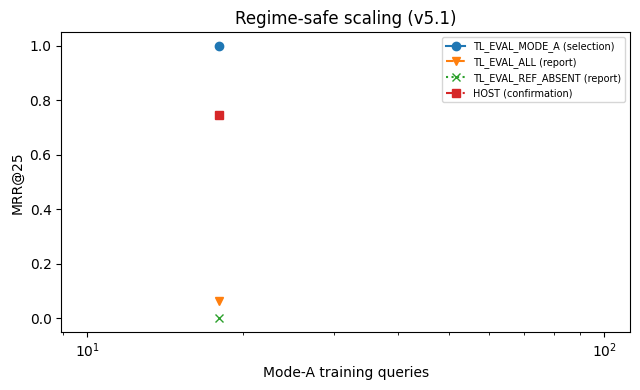

PROVISIONAL (not every TL Mode-A scale model trained yet) spectrum model -> C:\Users\myben\OneDrive\Documents\Enveda\outputs\v5\freeze\spectrum_model.json | route: RESOLVE_TEST_PROTOCOL


In [12]:
ci_a = tl_ci[tl_ci['population'] == 'TL_EVAL_MODE_A'].set_index('model')
freeze_rows = []
for m in list(MODELS) + ['B5_frozen_v4b']:
    r = RESULTS['tl_eval'][m]
    freeze_rows.append({'model': m, 'selected': m == SELECTED, 'n_train_queries': N_TRAIN.get(m),
                        'TL_EVAL_MODE_A_mrr': r['TL_EVAL_MODE_A']['mrr_at_25'], 'TL_EVAL_MODE_A_ci': (ci_a.loc[m, 'ci_low'], ci_a.loc[m, 'ci_high']),
                        'TL_EVAL_ALL_mrr': r['TL_EVAL_ALL']['mrr_at_25'], 'TL_EVAL_STANDARD_ONLY_mrr': r['TL_EVAL_STANDARD_ONLY']['mrr_at_25'],
                        'TL_EVAL_REF_ABSENT_mrr': r['TL_EVAL_REF_ABSENT']['mrr_at_25'], 'HOST_mrr': RESULTS['host'].get(m, {}).get('mrr_at_25'),
                        'HOST_density_reweighted_mrr': DENSITY.get(m, {}).get('estimate')})
freeze_table = pd.DataFrame(freeze_rows)
freeze_table.to_csv(D['metrics'] / 'v51_freeze_table.csv', index=False)
display(freeze_table)

sel_dir = D['models'] / SELECTED
man = MODE_A_MODEL_MANIFEST[SELECTED]
freeze = {
    'freeze_status': FREEZE_STATUS, 'stage': STAGE, 'rule_version': 'v5.1', 'model_id': SELECTED, 'model_dir': str(sel_dir),
    'manifest': man, 'manifest_hash': TRAIN_META[SELECTED]['manifest_sha256'], 'feature_names': BASE_FEATURES,
    'feature_order_hash': feature_order_hash(BASE_FEATURES), 'model_hashes': model_file_hashes(sel_dir),
    'mirror_aware_protocol_hash': mirror_aware_protocol_hash(), 'similarity_config_hash': SIM_HASH,
    'evidence_fingerprint': settlement['evidence_fingerprint'], 'lgbm_params': LGBM_PARAMS, 'seed': SEED, 'code_version': CODE_VERSION,
    'selection_population': 'TL_EVAL_MODE_A', 'tl_eval_population_metrics': RESULTS['tl_eval'][SELECTED],
    'host_confirmation_metrics': {**RESULTS['host'][SELECTED], 'ci': host_ci.set_index('model').loc[SELECTED, ['ci_low', 'ci_high']].to_dict()},
    'density_reweighted_host_estimate': {k: v for k, v in DENSITY[SELECTED].items() if k != 'table'},
    'k_stress': stress[(stress['model'] == SELECTED) & (stress['dataset'] != 'TL_EVAL_REF_ABSENT')][['dataset', 'k', 'mrr_at_25', 'hit_at_1']].to_dict('records'),
    'scaling_status': decision['scaling_status'], 'scale_decision': decision, 'project_route': ROUTE.get('project_route'),
    'selection_rule': V51_RULE, 'selection_rule_sha256': prereg['rule_sha256'], 'selection_lock': str(LOCK_PATH),
    'scoring': 'mean of 5 fold predictions; ties score DESC, abs_mass_error_ppm ASC, connectivity_key ASC',
    'frozen_at': pd.Timestamp.now(tz='UTC').isoformat(),
}
jdump(freeze, D['freeze'] / 'spectrum_model.json')
jdump({'status': STATUS, 'n_train_queries': N_TRAIN, 'tl_eval': RESULTS['tl_eval'], 'host': RESULTS['host'], 'oof_diagnostic': RESULTS['oof'],
       'scale_decision': decision, 'selected': SELECTED, 'freeze_status': FREEZE_STATUS, 'project_route': ROUTE.get('project_route'),
       'density_reweighted': {m: {k: v for k, v in d.items() if k != 'table'} for m, d in DENSITY.items()}}, D['root'] / 'scale_summary_v5_1.json')

fig, ax = plt.subplots(figsize=(6.5, 4))
pts = [m for m in MODE_A_HEADLINE_CANDIDATES if STATUS.get(m) == 'OK']
xs = [N_TRAIN[m] for m in pts]
for pop, style in (('TL_EVAL_MODE_A', 'o-'), ('TL_EVAL_ALL', 'v--'), ('TL_EVAL_REF_ABSENT', 'x:')):
    ax.plot(xs, [RESULTS['tl_eval'][m][pop]['mrr_at_25'] for m in pts], style, label=f'{pop} ({"selection" if pop.endswith("MODE_A") else "report"})')
ax.plot(xs, [RESULTS['host'][m]['mrr_at_25'] for m in pts], 's-.', label='HOST (confirmation)')
ax.set_xscale('log'); ax.set_xlabel('Mode-A training queries'); ax.set_ylabel('MRR@25'); ax.legend(fontsize=7); ax.set_title('Regime-safe scaling (v5.1)')
fig.tight_layout(); fig.savefig(D['figures'] / 'scale_curve_v5_1.png', dpi=130); plt.show()
print(FREEZE_STATUS, 'spectrum model ->', D['freeze'] / 'spectrum_model.json', '| route:', ROUTE.get('project_route'))